# Lab 06: Eigenvalues and Eigenvectors

An **eigenvalue** $\lambda$ and **eigenvector** $\mathbf{v}$ of a square matrix $A$ satisfy:
$$A\mathbf{v} = \lambda\mathbf{v}, \qquad \mathbf{v} \neq \mathbf{0}$$

Geometrically, $A$ only **scales** the eigenvector — it does not rotate it.
Eigenanalysis is fundamental to vibration analysis, stability of ODEs,
principal component analysis, and the convergence of iterative solvers (Lab 05).

## Learning Objectives

By the end of this session, you will be able to:
- Compute eigenvalues and eigenvectors with `numpy.linalg.eig` and verify key properties
- Implement and analyze the **Power Method** to find the dominant eigenvalue
- Find the smallest eigenvalue with the **Inverse Power Method**
- Find any eigenvalue with the **Shifted Power Method**
- Exploit the **spectral decomposition** of symmetric matrices
- Solve the **generalized eigenvalue problem** $K\mathbf{v} = \lambda M\mathbf{v}$ arising in vibration analysis
- Use eigenvalues to analyze the **stability** of a linear ODE system

## Session Outline

| # | Topic |  
|---|-------| 
| 1 | Definition, Geometric Interpretation, `numpy.linalg.eig` |  
| 2 | Power Method |  
| 3 | Inverse and Shifted Power Methods |  
| 4 | Symmetric Matrices and Spectral Decomposition |  
| 5 | Application: Vibration Analysis |  
| 6 | Application: ODE Systems and Stability | 

In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

---
## 1. Eigenvalues and Eigenvectors

### 1.1 Characteristic Polynomial

Rearranging $A\mathbf{v} = \lambda\mathbf{v}$:
$$(A - \lambda I)\mathbf{v} = \mathbf{0}$$

For a nontrivial solution ($\mathbf{v} \neq \mathbf{0}$), the matrix $(A - \lambda I)$ must be singular:
$$\det(A - \lambda I) = 0 \quad \leftarrow \text{characteristic equation}$$

For an $n\times n$ matrix this is a **degree-$n$ polynomial** in $\lambda$, yielding exactly $n$
eigenvalues (counting multiplicity, possibly complex).

**$2\times 2$ example:**
$$A = \begin{bmatrix} 3 & 1 \\ 1 & 3 \end{bmatrix},\qquad
\det(A - \lambda I) = (3-\lambda)^2 - 1 = \lambda^2 - 6\lambda + 8 = 0
\quad\Rightarrow\quad \lambda_1 = 4,\; \lambda_2 = 2$$

**Key properties** (valid for any square matrix):

| Property | Formula |
|----------|---------|
| Trace identity | $\text{tr}(A) = \sum_i a_{ii} = \sum_i \lambda_i$ |
| Determinant identity | $\det(A) = \prod_i \lambda_i$ |
| Rank | equals number of nonzero eigenvalues |

### 1.2 Geometric Interpretation

For most vectors $\mathbf{u}$, the image $A\mathbf{u}$ points in a **different direction**.
An eigenvector is special: $A\mathbf{v}$ is **exactly parallel** to $\mathbf{v}$ (only scaled by $\lambda$).

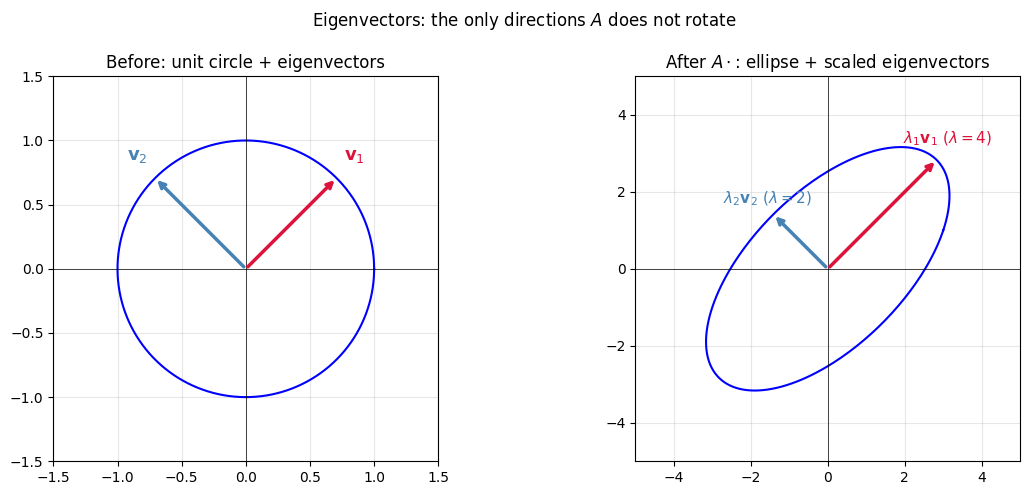

Eigenvalues: [4. 2.]


In [2]:
# Geometric: A transforms the unit circle into an ellipse.
# Eigenvectors align with the ellipse axes.
A_geo = np.array([[3.0, 1.0], [1.0, 3.0]])
eigvals_geo, eigvecs_geo = np.linalg.eig(A_geo)

theta   = np.linspace(0, 2 * np.pi, 300)
circle  = np.array([np.cos(theta), np.sin(theta)])
ellipse = A_geo @ circle

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['crimson', 'steelblue']

ax = axes[0]
ax.plot(circle[0], circle[1], 'b-', lw=1.5)
for i, (lam, c) in enumerate(zip(eigvals_geo, colors)):
    v = eigvecs_geo[:, i]
    ax.annotate('', xy=v, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ax.text(v[0]*1.2, v[1]*1.2, f'$\\mathbf{{v}}_{i+1}$', color=c, fontsize=13, ha='center')
ax.set(xlim=[-1.5,1.5], ylim=[-1.5,1.5], aspect='equal',
       title='Before: unit circle + eigenvectors')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ellipse[0], ellipse[1], 'b-', lw=1.5)
for i, (lam, c) in enumerate(zip(eigvals_geo, colors)):
    av = A_geo @ eigvecs_geo[:, i]   # = lam * v
    ax.annotate('', xy=av, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ax.text(av[0]*1.1, av[1]*1.1+0.15,
            f'$\\lambda_{i+1}\\mathbf{{v}}_{i+1}$ ($\\lambda={lam:.0f}$)',
            color=c, fontsize=11, ha='center')
ax.set(xlim=[-5,5], ylim=[-5,5], aspect='equal',
       title='After $A\\cdot$: ellipse + scaled eigenvectors')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.suptitle('Eigenvectors: the only directions $A$ does not rotate', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Eigenvalues: {eigvals_geo}')

### 1.3 Using `numpy.linalg.eig`

In [ ]:
# Lecture-notes example  (Ch. 13, Problem 13.1)
A = np.array([[20.0,  3.0,  2.0],
              [ 3.0,  9.0,  4.0],
              [ 2.0,  4.0, 12.0]])

# --- COMPLETE ---
eigvals, eigvecs =                                   # np.linalg.eig(A)
# --- COMPLETE ---

print('Eigenvalues:')
for i, lam in enumerate(eigvals):
    print(f'  lambda_{i+1} = {lam:.8f}')

print('\nEigenvectors (columns):')
print(np.round(eigvecs, 6))

# Verify  A v = lambda v
print('\nVerification  max|A v - lambda v|:')
for i in range(len(eigvals)):
    res = A @ eigvecs[:, i] - eigvals[i] * eigvecs[:, i]
    print(f'  lambda_{i+1}: {np.max(np.abs(res)):.2e}')

Eigenvalues:
  lambda_1 = 21.72915618
  lambda_2 = 13.18232626
  lambda_3 = 6.08851756

Eigenvectors (columns):
[[ 0.89819   0.427012  0.104481]
 [ 0.30972  -0.44601  -0.839732]
 [ 0.311976 -0.786598  0.532855]]

Verification  max|A v - lambda v|:
  lambda_1: 3.55e-15
  lambda_2: 7.11e-15
  lambda_3: 1.33e-15


<!-- SOLUTION
eigvals, eigvecs = np.linalg.eig(A)
-->

In [4]:
# Verify key algebraic properties
print('=== Key Properties ===')
print(f'trace(A)                = {np.trace(A):.6f}')
print(f'sum of eigenvalues      = {np.sum(eigvals):.6f}   <- must match')
print()
print(f'det(A)                  = {np.linalg.det(A):.6f}')
print(f'product of eigenvalues  = {np.prod(eigvals):.6f}   <- must match')
print()
# For a symmetric matrix, eigenvectors are orthonormal: V^T V = I
VTV = eigvecs.T @ eigvecs
print('V^T V (= I for symmetric A):')
print(np.round(VTV, 8))

=== Key Properties ===
trace(A)                = 41.000000
sum of eigenvalues      = 41.000000   <- must match

det(A)                  = 1744.000000
product of eigenvalues  = 1744.000000   <- must match

V^T V (= I for symmetric A):
[[ 1. -0. -0.]
 [-0.  1. -0.]
 [-0. -0.  1.]]


---
## 2. Power Method

### 2.1 Algorithm

`np.linalg.eig` computes **all** $n$ eigenpairs — an $O(n^3)$ operation.
For large matrices, only the **dominant** (largest $|\lambda|$) eigenvalue is often needed.
The **Power Method** computes it in $O(n^2)$ per iteration.

**Why does it work?**  
Expand $\mathbf{x}^{(0)}$ in the eigenbasis:
$\mathbf{x}^{(0)} = c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots$

Then:
$$A^k\mathbf{x}^{(0)} = \lambda_1^k\!\left[c_1\mathbf{v}_1 + c_2\!\left(\frac{\lambda_2}{\lambda_1}\right)^{\!k}\mathbf{v}_2 + \cdots\right]$$

If $|\lambda_1| > |\lambda_2|$, then $(\lambda_2/\lambda_1)^k \to 0$ and
$A^k\mathbf{x}^{(0)}$ aligns with $\mathbf{v}_1$. Convergence rate $\approx |\lambda_2/\lambda_1|$ per iteration.

**Algorithm** (normalize by the $\infty$-norm to prevent overflow):

Given $\mathbf{x}^{(0)} = \mathbf{1}$, for $k = 1, 2, \ldots$:
1. $\mathbf{y}^{(k)} = A\,\mathbf{x}^{(k-1)}$
2. $\lambda^{(k)} = y^{(k)}_{i^*}$ where $i^* = \arg\max_i |y_i^{(k)}|$ — eigenvalue estimate
3. $\mathbf{x}^{(k)} = \mathbf{y}^{(k)} / \lambda^{(k)}$ — normalize ($\|\mathbf{x}^{(k)}\|_\infty = 1$)

In [5]:
# Step-by-step trace (reproduces lecture-notes output)
x_k = np.ones(3)
print(f'{"Iter":>5}  {"lambda est":>12}  {"x1":>10}  {"x2":>10}  {"x3":>10}')
print('-' * 57)
for k in range(1, 8):
    y      = A @ x_k
    lam_k  = y[np.argmax(np.abs(y))]
    x_k    = y / lam_k
    print(f'{k:>5}  {lam_k:>12.6f}  {x_k[0]:>10.6f}  {x_k[1]:>10.6f}  {x_k[2]:>10.6f}')

print(f'\nTrue dominant lambda (numpy): {np.max(np.abs(eigvals)):.6f}')

 Iter    lambda est          x1          x2          x3
---------------------------------------------------------
    1     25.000000    1.000000    0.640000    0.720000
    2     23.360000    1.000000    0.498288    0.565068
    3     22.625000    1.000000    0.430712    0.476198
    4     22.244532    1.000000    0.394758    0.424249
    5     22.032771    1.000000    0.374434    0.393506
    6     21.910313    1.000000    0.362566    0.375157
    7     21.838011    1.000000    0.355514    0.364142

True dominant lambda (numpy): 21.729156


<!-- lam =                                         y[np.argmax(np.abs(y))] # — element with largest |value|
x   =                                         y / lam                 # — normalize -->

In [ ]:
def power_method(A, x0=None, tol=1e-8, max_iter=500):
    """
    Find the dominant eigenvalue and eigenvector of A using the Power Method.

    Parameters
    ----------
    A        : (n, n) array
    x0       : (n,)   initial guess  (default: ones)
    tol      : float  relative change in lambda as stopping criterion
    max_iter : int

    Returns
    -------
    lam      : float        — dominant eigenvalue
    v        : (n,) ndarray — eigenvector (inf-norm normalized)
    lam_hist : list         — eigenvalue estimate history
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]
    x = np.ones(n) if x0 is None else np.array(x0, dtype=float)
    lam_hist = []
    lam_old  = np.inf

    for _ in range(max_iter):
        y   = A @ x
        # --- COMPLETE ---
        lam =                                         
        x   =                                         
        # --- COMPLETE ---

        lam_hist.append(float(lam))
        if abs(lam - lam_old) / abs(lam) < tol:
            break
        lam_old = lam

    return float(lam), x, lam_hist

<!-- SOLUTION
lam = y[np.argmax(np.abs(y))]
x   = y / lam
-->

Converged in 51 iterations
Dominant eigenvalue (Power Method): 21.729156182199
True value (numpy)                : 21.729156182169
Absolute error                    : 3.02e-11

Theoretical convergence rate |λ₂/λ₁| = 0.606665
  -> error halves every 1.4 iterations


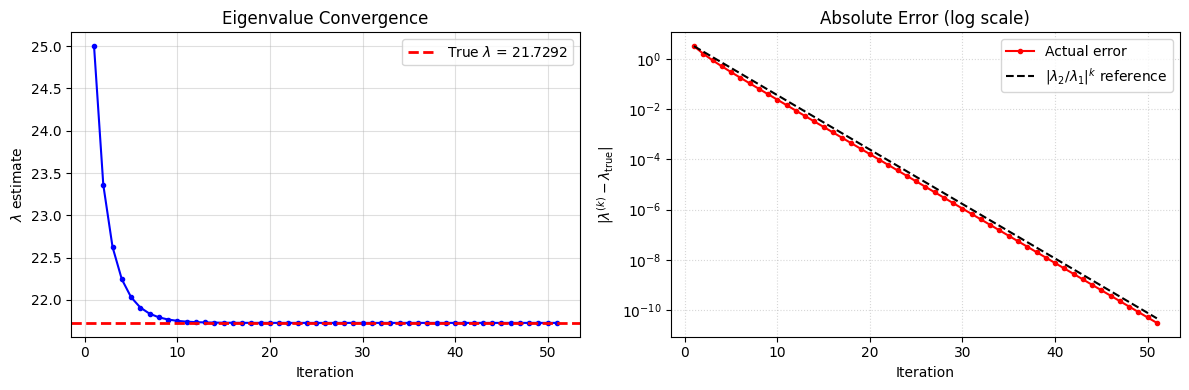

In [9]:
# Test power_method and analyze convergence
lam_pm, v_pm, hist_pm = power_method(A, tol=1e-12)
lam_true = float(eigvals[np.argmax(np.abs(eigvals))])

print(f'Converged in {len(hist_pm)} iterations')
print(f'Dominant eigenvalue (Power Method): {lam_pm:.12f}')
print(f'True value (numpy)                : {lam_true:.12f}')
print(f'Absolute error                    : {abs(lam_pm - lam_true):.2e}')

sorted_lam = np.sort(np.abs(eigvals))[::-1]
rate = sorted_lam[1] / sorted_lam[0]
print(f'\nTheoretical convergence rate |λ₂/λ₁| = {rate:.6f}')
print(f'  -> error halves every {-np.log(2)/np.log(rate):.1f} iterations')

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
iters = range(1, len(hist_pm)+1)

ax1.plot(iters, hist_pm, 'b.-', ms=6)
ax1.axhline(lam_true, color='r', ls='--', lw=2, label=f'True $\\lambda$ = {lam_true:.4f}')
ax1.set(xlabel='Iteration', ylabel='$\\lambda$ estimate', title='Eigenvalue Convergence')
ax1.legend(); ax1.grid(True, alpha=0.4)

errors = np.abs(np.array(hist_pm) - lam_true)
ax2.semilogy(iters, errors, 'r.-', ms=6, label='Actual error')
if len(errors) > 2:
    ref = errors[0] * rate**np.array(range(len(errors)))
    ax2.semilogy(iters, ref, 'k--', lw=1.5, label=f'$|\\lambda_2/\\lambda_1|^k$ reference')
ax2.set(xlabel='Iteration', ylabel='$|\\lambda^{(k)} - \\lambda_{\\rm true}|$',
        title='Absolute Error (log scale)')
ax2.legend(); ax2.grid(True, which='both', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 3. Inverse and Shifted Power Methods

### 3.1 Inverse Power Method — Smallest Eigenvalue

If $A\mathbf{v} = \lambda\mathbf{v}$, then $A^{-1}\mathbf{v} = (1/\lambda)\mathbf{v}$.
The **smallest** $|\lambda_i|$ of $A$ becomes the **largest** $|1/\lambda_i|$ of $A^{-1}$.

So applying the Power Method to $A^{-1}$ converges to $1/\lambda_{\min}$.

**Implementation:** never form $A^{-1}$ explicitly. Each iteration solves $A\mathbf{y} = \mathbf{x}$,
which costs only $O(n^2)$ after the LU factorization is computed once.

### 3.2 Shifted Power Method — Any Eigenvalue

Apply the Inverse Power Method to $(A - \sigma I)$ for a user-supplied **shift** $\sigma$:

$$\text{eigenvalues of }(A-\sigma I)^{-1}: \quad \frac{1}{\lambda_i - \sigma}$$

The eigenvalue **closest** to $\sigma$ has the largest $|1/(\lambda_i - \sigma)|$, so the
method converges to it. Setting $\sigma = 0$ recovers the inverse power method.

In [ ]:
def shifted_power_method(A, sigma=0.0, x0=None, tol=1e-8, max_iter=500):
    """
    Find the eigenvalue of A nearest to `sigma` (Shifted Inverse Power Method).

    Algorithm:
      1. Build B = A - sigma*I
      2. Factor B = LU  (once)
      3. Power iteration on B^{-1}: solve B y = x, normalize
      4. True eigenvalue:  lambda = sigma + 1/mu   where mu = max(|y|)

    sigma = 0  ->  Inverse Power Method  (finds smallest |lambda|)
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]
    x = np.ones(n) if x0 is None else np.array(x0, dtype=float)

    # --- COMPLETE ---
    B      = A - sigma * np.eye(n)                   # shifted matrix
    lu_obj =                                         # sc.linalg.lu_factor(B)
    # --- COMPLETE ---

    lam_hist = []
    lam_old  = np.inf

    for _ in range(max_iter):
        # --- COMPLETE ---
        y   =                                        # sc.linalg.lu_solve(lu_obj, x)
        mu  = y[np.argmax(np.abs(y))]                # largest element of y  (= 1 / (lambda - sigma))
        x   = y / mu
        lam =                                        # sigma + 1.0 / mu
        # --- COMPLETE ---

        lam_hist.append(float(lam))
        if abs(lam - lam_old) / (abs(lam) + 1e-30) < tol:
            break
        lam_old = lam

    return float(lam), x, lam_hist

<!-- SOLUTION
lu_obj = sc.linalg.lu_factor(B)
y      = sc.linalg.lu_solve(lu_obj, x)
lam    = sigma + 1.0 / mu
-->

In [12]:
# Find all three eigenvalues using different shifts
lam_sorted = np.sort(np.real(eigvals))
print(f'All eigenvalues (numpy, ascending): {np.round(lam_sorted, 6)}')
print()

tests = [
    ('Power Method   (dominant)', power_method,           dict(),           np.max(np.abs(eigvals))),
    ('sigma=0        (smallest)', shifted_power_method,   dict(sigma=0.0),  lam_sorted[0]),
    ('sigma=10       (middle)',   shifted_power_method,   dict(sigma=10.0), lam_sorted[1]),
    ('sigma=24       (largest)', shifted_power_method,   dict(sigma=24.0), lam_sorted[2]),
]

print(f'{"Method":<34}  {"Found lambda":>14}  {"True lambda":>12}  {"Error":>10}  {"Iters":>6}')
print('-' * 84)
for label, func, kwargs, lam_t in tests:
    lam_f, _, hist = func(A, tol=1e-12, **kwargs)
    print(f'{label:<34}  {lam_f:>14.8f}  {lam_t:>12.8f}  {abs(lam_f-lam_t):>10.2e}  {len(hist):>6}')

All eigenvalues (numpy, ascending): [ 6.088518 13.182326 21.729156]

Method                                Found lambda   True lambda       Error   Iters
------------------------------------------------------------------------------------
Power Method   (dominant)              21.72915618   21.72915618    3.02e-11      51
sigma=0        (smallest)               6.08851756    6.08851756    2.68e-12      38
sigma=10       (middle)                13.18232626   13.18232626    5.06e-12     127
sigma=24       (largest)               21.72915618   21.72915618    1.34e-12      18


---
## 4. Symmetric Matrices and Spectral Decomposition

### 4.1 Special Properties

For a **symmetric** matrix ($A = A^T$):

| Property | Statement |
|----------|-----------|
| Real eigenvalues | All $\lambda_i \in \mathbb{R}$ |
| Orthogonal eigenvectors | $\mathbf{v}_i^T \mathbf{v}_j = 0$ for $i \neq j$ |
| Orthonormal eigenbasis | $V^T V = V V^T = I$ |
| Spectral decomposition | $A = V \Lambda V^T = \displaystyle\sum_{i=1}^n \lambda_i\, \mathbf{v}_i\mathbf{v}_i^T$ |

Use **`np.linalg.eigh`** (not `eig`) for symmetric matrices:
it guarantees real output, sorts eigenvalues ascending, and runs about 2× faster.

### 4.2 Low-Rank Approximation

Truncating the spectral sum to the $k$ dominant terms gives the
**best rank-$k$ approximation** (in Frobenius norm):
$$A_k = \sum_{i=1}^{k} \lambda_i\, \mathbf{v}_i\mathbf{v}_i^T, \qquad
\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{n} \lambda_i^2}$$

In [13]:
# eigh: sorted, real, orthonormal
eigvals_h, V = np.linalg.eigh(A)   # ascending order
print('eigh eigenvalues (ascending):', np.round(eigvals_h, 8))
print('eig  eigenvalues (unsorted) :', np.round(np.sort(np.real(eigvals)), 8))

print('\nOrthonormality check  V^T V:')
print(np.round(V.T @ V, 10))

# Spectral decomposition  A = V Lambda V^T
Lambda = np.diag(eigvals_h)
A_reconstructed = V @ Lambda @ V.T
print(f'\nmax|A - V Lambda V^T| = {np.max(np.abs(A - A_reconstructed)):.2e}')

# Low-rank approximation
print('\nLow-rank approximation error ||A - A_k||_F:')
for k in [1, 2, 3]:
    idx = np.argsort(np.abs(eigvals_h))[::-1][:k]
    A_k = sum(eigvals_h[i] * np.outer(V[:,i], V[:,i]) for i in idx)
    err_F = np.linalg.norm(A - A_k, 'fro')
    err_theory = np.sqrt(np.sum(eigvals_h[np.argsort(np.abs(eigvals_h))[:-k]]**2))
    print(f'  k={k}: ||A - A_k||_F = {err_F:.6f}  (theory: {err_theory:.6f})')

eigh eigenvalues (ascending): [ 6.08851756 13.18232626 21.72915618]
eig  eigenvalues (unsorted) : [ 6.08851756 13.18232626 21.72915618]

Orthonormality check  V^T V:
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

max|A - V Lambda V^T| = 7.11e-15

Low-rank approximation error ||A - A_k||_F:
  k=1: ||A - A_k||_F = 14.520460  (theory: 14.520460)
  k=2: ||A - A_k||_F = 6.088518  (theory: 6.088518)
  k=3: ||A - A_k||_F = 0.000000  (theory: 0.000000)


---
## 5. Application: Vibration Analysis

### 5.1 Equations of Motion

Consider three masses connected by four springs (fixed walls at both ends):

```
Wall ─[k₁]─ m₁ ─[k₂]─ m₂ ─[k₃]─ m₃ ─[k₄]─ Wall
```

Newton's second law gives the free-vibration equation:
$$M\ddot{\mathbf{x}} + K\mathbf{x} = \mathbf{0}$$

Assuming harmonic motion $\mathbf{x}(t) = \mathbf{v}\sin(\omega t)$ leads to the
**generalized eigenvalue problem**:
$$K\mathbf{v} = \omega^2 M\mathbf{v}$$

where $\lambda = \omega^2$ is the squared **natural frequency** and $\mathbf{v}$ is the **mode shape**.

$$K = \begin{bmatrix} k_1+k_2 & -k_2 & 0 \\ -k_2 & k_2+k_3 & -k_3 \\ 0 & -k_3 & k_3+k_4 \end{bmatrix},
\qquad
M = \begin{bmatrix} m_1 & & \\ & m_2 & \\ & & m_3 \end{bmatrix}$$

`scipy.linalg.eigh(K, M)` solves the generalized SPD eigenvalue problem with eigenvalues in ascending order.

In [ ]:
# System parameters
k1, k2, k3, k4 = 40.0, 30.0, 20.0, 10.0   # N/m
m1, m2, m3     =  2.0,  1.5,  1.0          # kg

K_vib = np.array([
    [k1+k2,   -k2,      0],
    [  -k2, k2+k3,    -k3],
    [    0,   -k3,  k3+k4]
])
M_vib = np.diag([m1, m2, m3])

# Solve  K v = omega^2 M v
omega_sq, modes = sc.linalg.eigh(K_vib, M_vib)   # eigenvalues ascending

# --- COMPLETE ---
omega_n =                                        # np.sqrt(omega_sq)        #  — rad/s
freq_hz =                                        # omega_n / (2 * np.pi)    #  — Hz
# --- COMPLETE ---

print('=== Natural Frequencies ===')
print(f'{"Mode":>5}  {"omega^2":>14}  {"omega (rad/s)":>14}  {"f (Hz)":>10}  {"T (s)":>10}')
print('-' * 60)
for i in range(3):
    print(f'{i+1:>5}  {omega_sq[i]:>14.4f}  {omega_n[i]:>14.4f}  {freq_hz[i]:>10.4f}  {1/freq_hz[i]:>10.4f}')

print('\nMode shapes (columns = eigenvectors, M-normalized):')
print(np.round(modes, 6))

# Verify generalized eigenvalue equation
print('\nVerification  max|K v - omega^2 M v|:')
for i in range(3):
    v   = modes[:, i]
    res = K_vib @ v - omega_sq[i] * M_vib @ v
    print(f'  Mode {i+1}: {np.max(np.abs(res)):.2e}')

=== Natural Frequencies ===
 Mode         omega^2   omega (rad/s)      f (Hz)       T (s)
------------------------------------------------------------
    1          9.0470          3.0078      0.4787      2.0889
    2         32.3636          5.6889      0.9054      1.1045
    3         56.9227          7.5447      1.2008      0.8328

Mode shapes (columns = eigenvectors, M-normalized):
[[-0.329371  0.484607 -0.395817]
 [-0.569877  0.085174  0.578492]
 [-0.543958 -0.720715 -0.429743]]

Verification  max|K v - omega^2 M v|:
  Mode 1: 4.44e-15
  Mode 2: 7.11e-15
  Mode 3: 1.42e-14


<!-- SOLUTION
omega_n = np.sqrt(omega_sq)
freq_hz = omega_n / (2 * np.pi)
-->

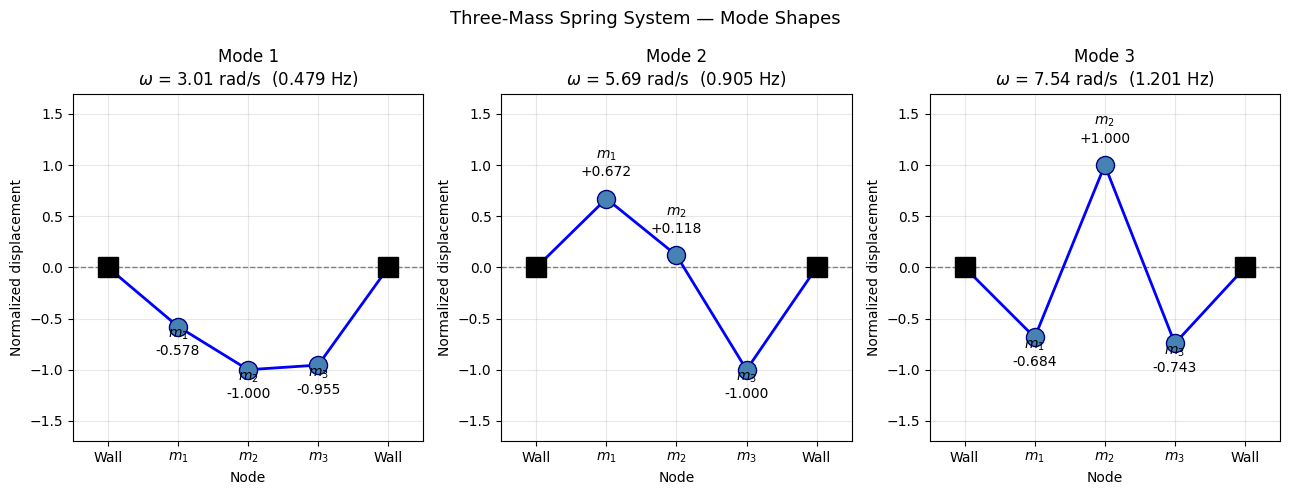

In [16]:
# Visualize mode shapes
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
x_pos    = [0, 1, 2, 3, 4]   # wall, m1, m2, m3, wall
x_masses = [1, 2, 3]

for i, ax in enumerate(axes):
    v      = modes[:, i]
    v_norm = v / np.max(np.abs(v))   # scale to max amplitude = 1
    disp   = np.array([0.0, v_norm[0], v_norm[1], v_norm[2], 0.0])

    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.plot(x_pos, disp, 'b-o', ms=13, lw=2, markerfacecolor='steelblue', markeredgecolor='navy')
    ax.plot([0, 4], [0, 0], 'ks', ms=14)   # walls

    for j, (xj, dj) in enumerate(zip(x_masses, v_norm)):
        offset = 0.22 if dj >= 0 else -0.28
        ax.text(xj, dj + offset, f'$m_{j+1}$\n{dj:+.3f}', ha='center', fontsize=10)

    ax.set(xlim=[-0.5, 4.5], ylim=[-1.7, 1.7],
           title=f'Mode {i+1}\n$\\omega$ = {omega_n[i]:.2f} rad/s  ({freq_hz[i]:.3f} Hz)',
           xlabel='Node', ylabel='Normalized displacement')
    ax.set_xticks(x_pos, ['Wall', '$m_1$', '$m_2$', '$m_3$', 'Wall'])
    ax.grid(True, alpha=0.3)

plt.suptitle('Three-Mass Spring System — Mode Shapes', fontsize=13)
plt.tight_layout()
plt.show()

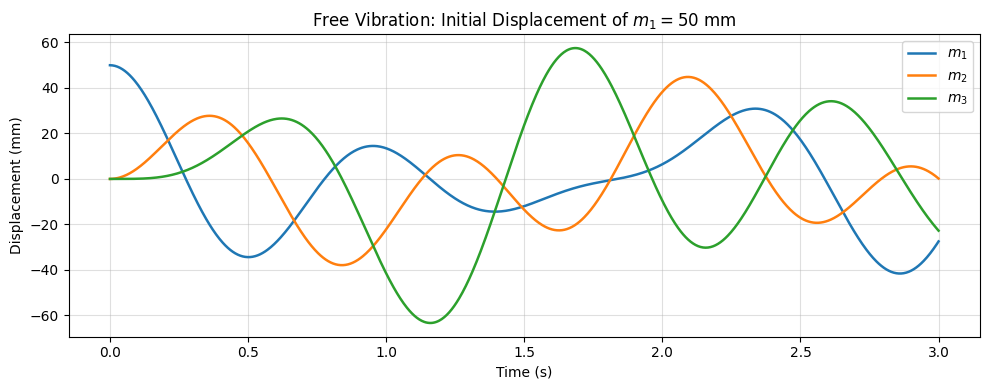

In [17]:
# Free-vibration time response: initial displacement x0 = [0.05, 0, 0] m
x0_vib  = np.array([0.05, 0.0, 0.0])
dx0_vib = np.zeros(3)

# Modal amplitudes: c_i = phi_i^T M x0,  s_i = phi_i^T M dx0 / omega_i
c_amp = modes.T @ M_vib @ x0_vib
s_amp = modes.T @ M_vib @ dx0_vib / (omega_n + 1e-30)

t = np.linspace(0, 3.0, 1000)
x_t = np.zeros((3, len(t)))
for i in range(3):
    x_t += np.outer(modes[:, i],
                    c_amp[i] * np.cos(omega_n[i] * t)
                    + s_amp[i] * np.sin(omega_n[i] * t))

fig, ax = plt.subplots(figsize=(10, 4))
for j in range(3):
    ax.plot(t, x_t[j] * 1000, lw=1.8, label=f'$m_{j+1}$')
ax.set(xlabel='Time (s)', ylabel='Displacement (mm)',
       title='Free Vibration: Initial Displacement of $m_1 = 50$ mm')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## 6. Application: ODE Systems and Stability

### 6.1 General Solution

For $\dot{\mathbf{y}} = A\mathbf{y}$, $\mathbf{y}(0) = \mathbf{y}_0$, the solution is:
$$\mathbf{y}(t) = \sum_{i=1}^{n} c_i\, \mathbf{v}_i\, e^{\lambda_i t}, \qquad
\mathbf{c} = V^{-1}\mathbf{y}_0$$

**Stability:**

| Condition | Behavior |
|-----------|----------|
| All $\text{Re}(\lambda_i) < 0$ | Solution **decays** → **asymptotically stable** |
| Any $\text{Re}(\lambda_i) > 0$ | Solution **grows** → **unstable** |
| All $\text{Re}(\lambda_i) \leq 0$, some $= 0$ | **marginally stable** |

### 6.2 Example (Lecture Problem 13.13)

$$\begin{cases} \dot{y}_1 = -5y_1 + 3y_2 \\ \dot{y}_2 = 100y_1 - 301y_2 \end{cases},
\qquad \mathbf{y}(0) = [50,\; 100]^T$$

Eigenvalues:
  lambda_1 = -3.989933   -> mode decays
  lambda_2 = -302.010067   -> mode decays
System is STABLE

Modal constants: c1 = 53.6413,  c2 = 82.8879


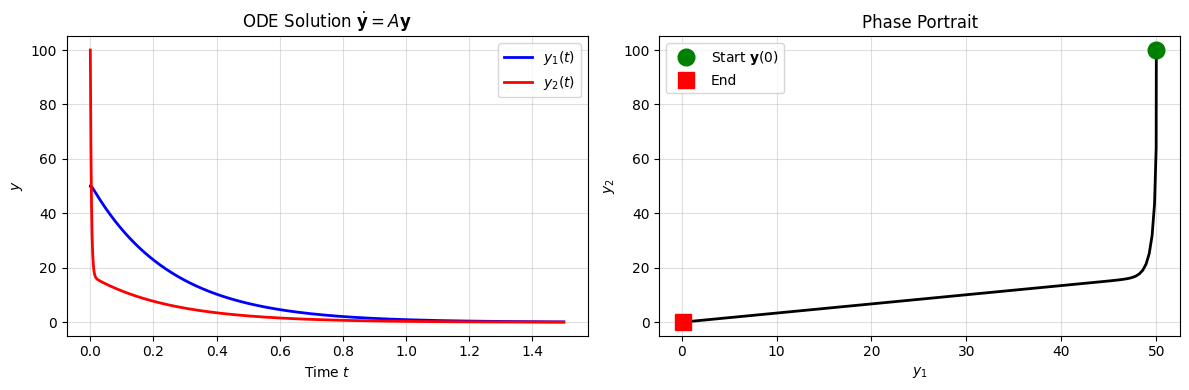


Time constants:  tau_1 = 1/|lambda_1| = 0.2506 s  (slow mode)
                 tau_2 = 1/|lambda_2| = 0.003311 s  (fast mode)
Stiffness ratio  |lambda_2 / lambda_1| = 75.7


In [ ]:
A_ode = np.array([[ -5.0,    3.0],
                  [100.0, -301.0]])
y0    = np.array([50.0, 100.0])

lam_ode, V_ode = np.linalg.eig(A_ode)
print('Eigenvalues:')
for i, lam in enumerate(lam_ode):
    status = 'decays' if np.real(lam) < 0 else 'GROWS'
    print(f'  lambda_{i+1} = {lam:.6f}   -> mode {status}')
stable = np.all(np.real(lam_ode) < 0)
print(f'System is {"STABLE" if stable else "UNSTABLE"}')

# --- COMPLETE: find modal constants c = V^{-1} y0 ---
c_ode =                                              # np.linalg.solve(V_ode, y0)
# --- COMPLETE ---

print(f'\nModal constants: c1 = {c_ode[0]:.4f},  c2 = {c_ode[1]:.4f}')

# Time solution
t = np.linspace(0, 1.5, 800)
y_t = np.zeros((2, len(t)))
for i in range(2):
    y_t += np.real(c_ode[i] * np.outer(V_ode[:, i], np.exp(lam_ode[i] * t)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(t, y_t[0], 'b-', lw=2, label='$y_1(t)$')
ax.plot(t, y_t[1], 'r-', lw=2, label='$y_2(t)$')
ax.set(xlabel='Time $t$', ylabel='$y$', title='ODE Solution $\\dot{\\mathbf{y}} = A\\mathbf{y}$')
ax.legend(); ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(y_t[0], y_t[1], 'k-', lw=2)
ax.plot(y0[0], y0[1], 'go', ms=12, label='Start $\\mathbf{y}(0)$', zorder=5)
ax.plot(y_t[0,-1], y_t[1,-1], 'rs', ms=12, label='End', zorder=5)
ax.set(xlabel='$y_1$', ylabel='$y_2$', title='Phase Portrait')
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'\nTime constants:  tau_1 = 1/|lambda_1| = {1/abs(lam_ode[0]):.4f} s  (slow mode)')
print(f'                 tau_2 = 1/|lambda_2| = {1/abs(lam_ode[1]):.6f} s  (fast mode)')
print(f'Stiffness ratio  |lambda_2 / lambda_1| = {abs(lam_ode[1]/lam_ode[0]):.1f}')

<!-- SOLUTION
c_ode = np.linalg.solve(V_ode, y0)
-->

---
## Summary

### Methods Overview

| Method | Finds | Cost | Notes |
|--------|-------|------|-------|
| `np.linalg.eig(A)` | All $n$ eigenpairs | $O(n^3)$ | General matrices; may give complex values |
| `np.linalg.eigh(A)` | All $n$ eigenpairs | $O(n^3)$ | Symmetric only; real, sorted ascending |
| **Power Method** | Dominant $\lambda$ | $O(n^2)$/iter | Rate $\approx|\lambda_2/\lambda_1|$ |
| **Inverse Power** | Smallest $|\lambda|$ | $O(n^2)$/iter (after LU) | Use $\sigma=0$ in shifted method |
| **Shifted Power** | $\lambda$ nearest to $\sigma$ | $O(n^2)$/iter (after LU) | Choose $\sigma$ close to target |
| `sc.linalg.eigh(K, M)` | Generalized $K\mathbf{v}=\lambda M\mathbf{v}$ | $O(n^3)$ | SPD pair; natural frequencies |

### Key Formulas

| Concept | Formula |
|---------|--------|
| **Characteristic equation** | $\det(A - \lambda I) = 0$ |
| **Trace identity** | $\text{tr}(A) = \sum_i \lambda_i$ |
| **Determinant identity** | $\det(A) = \prod_i \lambda_i$ |
| **Power step** | $\lambda^{(k)} = \max|A\mathbf{x}^{(k-1)}|$,\; $\mathbf{x}^{(k)} = A\mathbf{x}^{(k-1)}/\lambda^{(k)}$ |
| **Spectral decomposition** | $A = V\Lambda V^T$ (symmetric $A$, $V^TV = I$) |
| **Natural frequency** | $\omega_i = \sqrt{\lambda_i}$ from $K\mathbf{v} = \lambda M\mathbf{v}$ |
| **ODE solution** | $\mathbf{y}(t) = \sum_i c_i \mathbf{v}_i e^{\lambda_i t}$,\; $\mathbf{c} = V^{-1}\mathbf{y}_0$ |
| **Stability** | Stable $\Leftrightarrow$ all $\text{Re}(\lambda_i) < 0$ |

### Engineering Context

| Application | Eigenvalue meaning | Eigenvector meaning |
|-------------|--------------------|-----------------------|
| **Structural vibration** | $\lambda = \omega^2$ (squared natural freq.) | Mode shape |
| **ODE system** | Decay/growth rate $e^{\lambda t}$ | Mode direction in state space |
| **Iterative solvers (Lab 05)** | Spectral radius $\rho(T)$ | Convergence direction |
| **Condition number (Lab 04)** | $\kappa = \lambda_{\max}/\lambda_{\min}$ | — |